# Procedural Frozen Lake

`Procedural-FrozenLake-v1` is a custom environment included with mouse-env. Unlike the standard `FrozenLake-v1` (fixed 4×4 map), it generates a **fresh random map every episode** — different grid size, different hole placement, different start and goal positions. This prevents overfitting to a single layout and is useful for continual or multi-task training.

The env also includes built-in Q* support: pass `q_star_source={"provider": "metadata_q_star"}` and the env runs value iteration internally for each new map, injecting exact optimal Q-values into every step's output. This means the agent always has access to a fresh optimal policy even though the map changes every episode.

## Imports

In [1]:
import numpy as np
import torch

from mouse_envs import EnvConfig, make_env

## Build the environment

`step_penalty=-0.01` is passed via `kwargs`. Without a step penalty the env solves with `gamma=1.0`, so every hole-avoiding action shares the same Q* value and greedy tie-breaking can wander. A small penalty makes value iteration prefer shorter paths, turning `argmax(q_star)` into a true shortest-path expert.

In [2]:
cfg = EnvConfig(
    id="Procedural-FrozenLake-v1",
    seed=7,
    num_envs=1,
    max_episode_steps=200,
    q_star_source={"provider": "metadata_q_star"},
    kwargs={"step_penalty": -0.01},
)
env = make_env(cfg)

## Inspect the reset frame

The first `step` performs the internal reset and already includes `q_star` for the start state of the first randomly generated map.

In [3]:
[(outputs, metrics)] = env.step(env.sample_random_inputs())

print(f"observation (state index): {outputs[0]['observation'].tolist()}")
print(f"q_star:                    {outputs[0]['q_star'].round(3)}")
print(f"greedy action:             {int(np.argmax(outputs[0]['q_star']))}")

observation (state index): 12
q_star:                    [ 0.95  0.95 -0.01  0.97]
greedy action:             3


## Expert rollout across episodes

Each time an episode ends, the env resets to a **new random map** and value iteration recomputes Q* for that map. The `q_star` in the reset frame already reflects the new layout, so greedy `argmax` is immediately valid without any extra steps.

In [4]:
episodes = 0

for step in range(400):
    inputs_per_env = [[{
        "action": torch.tensor(int(np.argmax(outputs[0]["q_star"])), dtype=torch.int64)
    }]]
    [(outputs, metrics)] = env.step(inputs_per_env)

    r = outputs[0]
    if r["done"].item() != 0:
        episodes += 1
        done_code = r["done"].item()
        outcome = "terminated" if done_code == 1 else "truncated"
        print(
            f"step={step:3d}  episode={episodes}  outcome={outcome}  "
            f"reward={r['reward'].item():.2f}"
        )

step=  2  episode=1  outcome=terminated  reward=0.99
step=  6  episode=2  outcome=terminated  reward=0.99
step= 10  episode=3  outcome=terminated  reward=0.99
step= 14  episode=4  outcome=terminated  reward=0.99
step= 18  episode=5  outcome=terminated  reward=0.99
step= 22  episode=6  outcome=terminated  reward=0.99
step= 26  episode=7  outcome=terminated  reward=0.99
step= 30  episode=8  outcome=terminated  reward=0.99
step= 34  episode=9  outcome=terminated  reward=0.99
step= 38  episode=10  outcome=terminated  reward=0.99
step= 42  episode=11  outcome=terminated  reward=0.99
step= 46  episode=12  outcome=terminated  reward=0.99
step= 50  episode=13  outcome=terminated  reward=0.99
step= 54  episode=14  outcome=terminated  reward=0.99
step= 58  episode=15  outcome=terminated  reward=0.99
step= 62  episode=16  outcome=terminated  reward=0.99
step= 66  episode=17  outcome=terminated  reward=0.99
step= 70  episode=18  outcome=terminated  reward=0.99
step= 74  episode=19  outcome=termina

## With vs without the expert

To quantify what the Q* attachment provides, run many episodes two ways and compare episode success rate (FrozenLake gives `reward = 1` only on reaching the goal): **with the expert** (greedy `argmax` over `q_star`) vs **without** (random actions). The greedy-Q* policy requires no trained network — it reads exact Q-values the wrapper attaches each step, freshly computed for each new map.

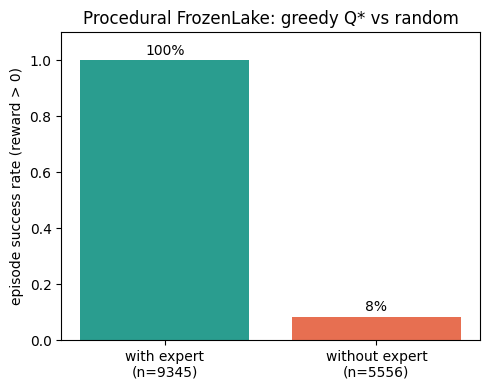

In [5]:
import matplotlib.pyplot as plt


def evaluate(use_expert, *, steps=800, seed=7, num_envs=64):
    cfg = EnvConfig(
        id="Procedural-FrozenLake-v1",
        seed=seed,
        num_envs=num_envs,
        max_episode_steps=200,
        q_star_source={"provider": "metadata_q_star"},
        kwargs={"step_penalty": -0.01},
    )
    env = make_env(cfg)
    [(outputs, metrics)] = env.step(env.sample_random_inputs())
    episode_rewards = []
    for _ in range(steps):
        if use_expert:
            inputs_per_env = [[{
                "action": torch.tensor(
                    int(np.argmax(outputs[i]["q_star"])),
                    dtype=torch.int64,
                )
            } for i in range(env.num_envs)]]
        else:
            inputs_per_env = env.sample_random_inputs()
        [(outputs, metrics)] = env.step(inputs_per_env)
        for m in metrics:
            episode_rewards.extend(m["episode_cum_reward"])
    env.close()
    return np.array(episode_rewards)


expert_eps = evaluate(use_expert=True)
random_eps = evaluate(use_expert=False)

success = [float((expert_eps > 0).mean()), float((random_eps > 0).mean())]
labels = [f"with expert\n(n={len(expert_eps)})", f"without expert\n(n={len(random_eps)})"]

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(labels, success, color=["#2a9d8f", "#e76f51"])
ax.set_ylim(0, 1.1)
ax.set_ylabel("episode success rate (reward > 0)")
ax.set_title("Procedural FrozenLake: greedy Q* vs random")
for bar, rate in zip(bars, success):
    ax.text(bar.get_x() + bar.get_width() / 2, rate + 0.02, f"{rate:.0%}", ha="center")
fig.tight_layout()
plt.show()

## Cleanup

In [6]:
env.close()